# 📊 Análisis Exploratorio de Datos - Saratoga Houses

## Sistema Profesional de Predicción de Precios de Alquiler

Este notebook contiene un análisis exploratorio completo del dataset SaratogaHouses, que incluye:
- Análisis estadístico descriptivo
- Visualizaciones de distribuciones
- Análisis de correlaciones
- Detección de outliers
- Feature engineering preliminar
- Insights para el modelado

## 1. Configuración e Importación de Librerías

In [1]:
# Data manipulation
import numpy as np
import pandas as pd
from pathlib import Path

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Statistical analysis
from scipy import stats
from scipy.stats import skew, kurtosis, norm, probplot
from sklearn.preprocessing import StandardScaler, RobustScaler

# Settings
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

# Visualization settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Set random seed for reproducibility
np.random.seed(42)

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


## 2. Carga de Datos

In [2]:
# Definir rutas
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "SaratogaHouses.csv"

# Cargar datos
df = pd.read_csv(DATA_PATH)

print(f"📊 Dataset cargado exitosamente")
print(f"   - Dimensiones: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"   - Memoria utilizada: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

📊 Dataset cargado exitosamente
   - Dimensiones: 1,728 filas × 16 columnas
   - Memoria utilizada: 0.75 MB


## 3. Vista General de los Datos

In [4]:
# Primeras filas
print("=" * 80)
print("📋 PRIMERAS 10 FILAS DEL DATASET")
print("=" * 80)
display(df.head(10))

print("\n" + "=" * 80)
print("📋 ÚLTIMAS 10 FILAS DEL DATASET")
print("=" * 80)
display(df.tail(10))

📋 PRIMERAS 10 FILAS DEL DATASET


,price,lotSize,age,landValue,livingArea,pctCollege,bedrooms,fireplaces,bathrooms,rooms,heating,fuel,sewer,waterfront,newConstruction,centralAir
0,132500,0.09,42,50000,906,35,2,1,1.00,5,electric,electric,septic,No,No,No
1,181115,0.92,0,22300,1953,51,3,0,2.50,6,hot water/steam,gas,septic,No,No,No
2,109000,0.19,133,7300,1944,51,4,1,1.00,8,hot water/steam,gas,public/commercial,No,No,No
3,155000,0.41,13,18700,1944,51,3,1,1.50,5,hot air,gas,septic,No,No,No
4,86060,0.11,0,15000,840,51,2,0,1.00,3,hot air,gas,public/commercial,No,Yes,Yes
5,120000,0.68,31,14000,1152,22,4,1,1.00,8,hot air,gas,septic,No,No,No
6,153000,0.40,33,23300,2752,51,4,1,1.50,8,hot water/steam,oil,septic,No,No,No
7,170000,1.21,23,14600,1662,35,4,1,1.50,9,hot air,oil,septic,No,No,No
8,90000,0.83,36,22200,1632,51,3,0,1.50,8,electric,electric,septic,No,No,No
9,122900,1.94,4,21200,1416,44,3,0,1.50,6,hot air,gas,none,No,No,No



📋 ÚLTIMAS 10 FILAS DEL DATASET


,price,lotSize,age,landValue,livingArea,pctCollege,bedrooms,fireplaces,bathrooms,rooms,heating,fuel,sewer,waterfront,newConstruction,centralAir
1718,183500,0.28,57,23200,1121,61,3,0,1.50,4,hot air,oil,septic,No,No,No
1719,275900,0.81,0,7300,2288,61,3,1,2.50,8,hot air,gas,public/commercial,No,Yes,No
1720,436023,0.41,5,43400,2718,61,4,1,2.50,12,hot air,gas,public/commercial,No,No,Yes
1721,319900,0.58,42,31400,2464,61,4,1,2.50,8,hot water/steam,gas,public/commercial,No,No,No
1722,249000,0.43,41,45800,2426,61,4,2,2.00,7,hot water/steam,gas,public/commercial,No,No,No
1723,289000,0.38,32,24200,2310,61,5,1,2.50,11,hot water/steam,gas,public/commercial,No,No,No
1724,285000,0.94,37,36200,2564,61,4,1,2.50,11,hot water/steam,gas,public/commercial,No,No,No
1725,194900,0.39,9,20400,1099,51,2,0,1.00,3,hot air,gas,public/commercial,No,No,No
1726,125000,0.24,48,16800,1225,51,3,1,1.00,7,hot air,gas,public/commercial,No,No,No
1727,111300,0.59,86,26000,1959,51,3,0,1.00,6,hot air,gas,septic,No,No,No


In [5]:
# Información del dataset
print("=" * 80)
print("📊 INFORMACIÓN DEL DATASET")
print("=" * 80)
df.info(verbose=True, show_counts=True)

📊 INFORMACIÓN DEL DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   price            1728 non-null   int64  
 1   lotSize          1728 non-null   float64
 2   age              1728 non-null   int64  
 3   landValue        1728 non-null   int64  
 4   livingArea       1728 non-null   int64  
 5   pctCollege       1728 non-null   int64  
 6   bedrooms         1728 non-null   int64  
 7   fireplaces       1728 non-null   int64  
 8   bathrooms        1728 non-null   float64
 9   rooms            1728 non-null   int64  
 10  heating          1728 non-null   object 
 11  fuel             1728 non-null   object 
 12  sewer            1728 non-null   object 
 13  waterfront       1728 non-null   object 
 14  newConstruction  1728 non-null   object 
 15  centralAir       1728 non-null   object 
dtypes: float64(2), int64(8), object(6)

In [6]:
# Descripción de columnas
column_descriptions = {
    "price": "💰 Precio de la vivienda (variable objetivo)",
    "lotSize": "📐 Metros cuadrados del terreno",
    "age": "📅 Antigüedad de la vivienda (años)",
    "landValue": "🏞️ Valor del terreno",
    "livingArea": "🏠 Metros cuadrados habitables",
    "pctCollege": "🎓 Porcentaje del vecindario con título universitario",
    "bedrooms": "🛏️ Número de dormitorios",
    "fireplaces": "🔥 Número de chimeneas",
    "bathrooms": "🚿 Número de cuartos de baño (0.5 = sin ducha)",
    "rooms": "🚪 Número de habitaciones",
    "heating": "🌡️ Tipo de calefacción",
    "fuel": "⛽ Tipo de combustible para calefacción",
    "sewer": "🚰 Tipo de desagüe",
    "waterfront": "🌊 Vista al lago",
    "newConstruction": "🏗️ Nueva construcción",
    "centralAir": "❄️ Aire acondicionado central"
}

desc_df = pd.DataFrame({
    "Columna": list(column_descriptions.keys()),
    "Descripción": list(column_descriptions.values()),
    "Tipo de Dato": [df[col].dtype for col in column_descriptions.keys()],
    "Valores Únicos": [df[col].nunique() for col in column_descriptions.keys()],
    "% Nulos": [(df[col].isnull().sum() / len(df) * 100) for col in column_descriptions.keys()]
})

display(desc_df)

,Columna,Descripción,Tipo de Dato,Valores Únicos,% Nulos
0,price,💰 Precio de la vivienda (variable objetivo),int64,751,0.00
1,lotSize,📐 Metros cuadrados del terreno,float64,170,0.00
2,age,📅 Antigüedad de la vivienda (años),int64,136,0.00
3,landValue,🏞️ Valor del terreno,int64,573,0.00
4,livingArea,🏠 Metros cuadrados habitables,int64,877,0.00
5,pctCollege,🎓 Porcentaje del vecindario con título univers...,int64,32,0.00
6,bedrooms,🛏️ Número de dormitorios,int64,7,0.00
7,fireplaces,🔥 Número de chimeneas,int64,5,0.00
8,bathrooms,🚿 Número de cuartos de baño (0.5 = sin ducha),float64,9,0.00
9,rooms,🚪 Número de habitaciones,int64,11,0.00


## 4. Análisis de Valores Nulos y Duplicados

In [7]:
# Análisis de valores nulos
print("=" * 80)
print("🔍 ANÁLISIS DE VALORES NULOS")
print("=" * 80)

null_counts = df.isnull().sum()
null_percentages = (df.isnull().sum() / len(df) * 100).round(2)

null_df = pd.DataFrame({
    "Columna": null_counts.index,
    "Nulos": null_counts.values,
    "% Nulos": null_percentages.values
})
null_df = null_df[null_df["Nulos"] > 0].sort_values("Nulos", ascending=False)

if len(null_df) > 0:
    display(null_df)
else:
    print("✅ No hay valores nulos en el dataset")

# Análisis de duplicados
print("\n" + "=" * 80)
print("🔍 ANÁLISIS DE DUPLICADOS")
print("=" * 80)

duplicate_count = df.duplicated().sum()
print(f"Filas duplicadas: {duplicate_count}")

if duplicate_count > 0:
    print(f"\nPrimeras filas duplicadas:")
    display(df[df.duplicated(keep=False)].head(10))

🔍 ANÁLISIS DE VALORES NULOS
✅ No hay valores nulos en el dataset

🔍 ANÁLISIS DE DUPLICADOS
Filas duplicadas: 7

Primeras filas duplicadas:


,price,lotSize,age,landValue,livingArea,pctCollege,bedrooms,fireplaces,bathrooms,rooms,heating,fuel,sewer,waterfront,newConstruction,centralAir
853,131600,0.16,17,15100,1385,54,2,1,1.50,7,electric,electric,public/commercial,No,No,No
858,105000,0.16,20,15700,912,54,2,0,1.50,3,electric,electric,public/commercial,No,No,No
859,122500,0.15,18,15100,1184,54,2,0,1.50,3,electric,electric,public/commercial,No,No,No
865,188900,0.32,18,27000,1294,54,3,0,1.00,4,electric,electric,public/commercial,No,No,No
869,126000,0.16,17,15600,908,54,2,0,1.00,4,electric,electric,public/commercial,No,No,No
882,190000,0.59,15,25000,1300,54,3,1,1.50,5,hot air,gas,septic,No,No,Yes
898,131600,0.16,17,15100,1385,54,2,1,1.50,7,electric,electric,public/commercial,No,No,No
903,105000,0.16,20,15700,912,54,2,0,1.50,3,electric,electric,public/commercial,No,No,No
904,122500,0.15,18,15100,1184,54,2,0,1.50,3,electric,electric,public/commercial,No,No,No
910,188900,0.32,18,27000,1294,54,3,0,1.00,4,electric,electric,public/commercial,No,No,No


## 5. Análisis Estadístico Descriptivo

In [8]:
# Variables numéricas
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print("=" * 80)
print("📈 ESTADÍSTICAS DESCRIPTIVAS - VARIABLES NUMÉRICAS")
print("=" * 80)

# Estadísticas básicas
desc_stats = df[numeric_cols].describe().T
desc_stats['range'] = desc_stats['max'] - desc_stats['min']
desc_stats['skewness'] = df[numeric_cols].skew()
desc_stats['kurtosis'] = df[numeric_cols].kurtosis()
desc_stats['cv'] = (desc_stats['std'] / desc_stats['mean'] * 100)  # Coeficiente de variación

display(desc_stats.round(2))

📈 ESTADÍSTICAS DESCRIPTIVAS - VARIABLES NUMÉRICAS


,count,mean,std,min,25%,50%,75%,max,range,skewness,kurtosis,cv
price,1728.00,211966.71,98441.39,5000.00,145000.00,189900.00,259000.00,775000.00,770000.00,1.58,4.19,46.44
lotSize,1728.00,0.50,0.70,0.00,0.17,0.37,0.54,12.20,12.20,7.19,78.42,139.68
age,1728.00,27.92,29.21,0.00,13.00,19.00,34.00,225.00,225.00,2.50,7.42,104.63
landValue,1728.00,34557.19,35021.17,200.00,15100.00,25000.00,40200.00,412600.00,412400.00,3.10,16.20,101.34
livingArea,1728.00,1754.98,619.94,616.00,1300.00,1634.50,2137.75,5228.00,4612.00,0.90,1.27,35.32
pctCollege,1728.00,55.57,10.33,20.00,52.00,57.00,64.00,82.00,62.00,-1.04,0.61,18.60
bedrooms,1728.00,3.15,0.82,1.00,3.00,3.00,4.00,7.00,6.00,0.40,0.66,25.91
fireplaces,1728.00,0.60,0.56,0.00,0.00,1.00,1.00,4.00,4.00,0.40,0.73,92.40
bathrooms,1728.00,1.90,0.66,0.00,1.50,2.00,2.50,4.50,4.50,0.32,-0.44,34.65
rooms,1728.00,7.04,2.32,2.00,5.00,7.00,8.25,12.00,10.00,0.28,-0.59,32.90


In [9]:
# Variables categóricas
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print("=" * 80)
print("📊 ESTADÍSTICAS DESCRIPTIVAS - VARIABLES CATEGÓRICAS")
print("=" * 80)

for col in categorical_cols:
    print(f"\n{col.upper()}:")
    print("-" * 40)
    value_counts = df[col].value_counts()
    value_pcts = df[col].value_counts(normalize=True) * 100
    
    summary_df = pd.DataFrame({
        'Conteo': value_counts,
        'Porcentaje (%)': value_pcts.round(2)
    })
    display(summary_df)

📊 ESTADÍSTICAS DESCRIPTIVAS - VARIABLES CATEGÓRICAS

HEATING:
----------------------------------------


,Conteo,Porcentaje (%)
heating,,
hot air,1121,64.87
electric,305,17.65
hot water/steam,302,17.48



FUEL:
----------------------------------------


,Conteo,Porcentaje (%)
fuel,,
gas,1197,69.27
electric,315,18.23
oil,216,12.50



SEWER:
----------------------------------------


...

,Conteo,Porcentaje (%)
waterfront,,
No,1713,99.13
Yes,15,0.87



NEWCONSTRUCTION:
----------------------------------------


,Conteo,Porcentaje (%)
newConstruction,,
No,1647,95.31
Yes,81,4.69



CENTRALAIR:
----------------------------------------


,Conteo,Porcentaje (%)
centralAir,,
No,1093,63.25
Yes,635,36.75


## 6. Análisis de la Variable Objetivo: PRICE

In [10]:
# Análisis detallado de la variable objetivo
target_col = 'price'

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        'Distribución del Precio',
        'Boxplot del Precio',
        'Q-Q Plot (Normalidad)',
        'Histograma + KDE'
    )
)

# Histograma
fig.add_trace(
    go.Histogram(x=df[target_col], nbinsx=50, name='Precio', marker_color='#1f77b4'),
    row=1, col=1
)

# Boxplot
fig.add_trace(
    go.Box(x=df[target_col], name='Precio', marker_color='#ff7f0e'),
    row=1, col=2
)

# Q-Q Plot
from scipy import stats
theoretical_quantiles = stats.norm.ppf((np.arange(len(df)) + 0.5) / len(df))
sample_quantiles = np.sort(df[target_col].values)

fig.add_trace(
    go.Scatter(x=theoretical_quantiles, y=sample_quantiles, mode='markers',
               marker=dict(size=3, color='#2ca02c'), name='Q-Q'),
    row=2, col=1
)
fig.add_trace(
    go.Scatter(x=theoretical_quantiles, y=theoretical_quantiles * sample_quantiles.std() + sample_quantiles.mean(),
               mode='lines', name='Normal', line=dict(color='red', dash='dash')),
    row=2, col=1
)

# KDE
hist_data = go.Histogram(x=df[target_col], nbinsx=50, name='Histograma', 
                         histnorm='probability density', marker_color='#1f77b4')
kde_x = np.linspace(df[target_col].min(), df[target_col].max(), 100)
kde = stats.gaussian_kde(df[target_col])
kde_y = kde(kde_x)

fig.add_trace(hist_data, row=2, col=2)
fig.add_trace(
    go.Scatter(x=kde_x, y=kde_y, mode='lines', name='KDE', line=dict(color='red', width=2)),
    row=2, col=2
)

fig.update_layout(height=800, showlegend=True, title_text="Análisis de la Variable Objetivo: PRICE")
fig.show()

# Estadísticas adicionales
print("\n" + "=" * 80)
print("📊 ESTADÍSTICAS DETALLADAS DEL PRECIO")
print("=" * 80)

price_stats = {
    'Media': df[target_col].mean(),
    'Mediana': df[target_col].median(),
    'Moda': df[target_col].mode().values[0] if not df[target_col].mode().empty else np.nan,
    'Desviación Estándar': df[target_col].std(),
    'Varianza': df[target_col].var(),
    'Mínimo': df[target_col].min(),
    'Máximo': df[target_col].max(),
    'Rango': df[target_col].max() - df[target_col].min(),
    'Q1 (25%)': df[target_col].quantile(0.25),
    'Q3 (75%)': df[target_col].quantile(0.75),
    'IQR': df[target_col].quantile(0.75) - df[target_col].quantile(0.25),
    'Skewness': df[target_col].skew(),
    'Kurtosis': df[target_col].kurtosis(),
    'Coef. Variación (%)': (df[target_col].std() / df[target_col].mean() * 100)
}

for key, value in price_stats.items():
    if key in ['Media', 'Mediana', 'Moda', 'Desviación Estándar', 'Varianza', 
               'Mínimo', 'Máximo', 'Rango', 'Q1 (25%)', 'Q3 (75%)', 'IQR']:
        print(f"{key:25s}: ${value:>15,.2f}")
    else:
        print(f"{key:25s}: {value:>18.4f}")

# Test de normalidad
from scipy.stats import shapiro, normaltest
print("\n" + "-" * 40)
print("🔬 TEST DE NORMALIDAD")
print("-" * 40)

sample_for_test = df[target_col].sample(min(5000, len(df)), random_state=42)
stat, p_value = normaltest(sample_for_test)
print(f"D'Agostino-Pearson test: statistic={stat:.4f}, p-value={p_value:.4e}")
print(f"Interpretación: {'No normal' if p_value < 0.05 else 'Normal'} (p < 0.05)")

# Log transformation suggestion
log_price = np.log1p(df[target_col])
log_skew = skew(log_price)
print(f"\nSkewness después de log-transform: {log_skew:.4f}")
print(f"Recomendación: {'Considerar transformación logarítmica' if abs(log_skew) < abs(price_stats['Skewness']) else 'No es necesaria transformación'}")


📊 ESTADÍSTICAS DETALLADAS DEL PRECIO
Media                    : $     211,966.71
Mediana                  : $     189,900.00
Moda                     : $     120,000.00
Desviación Estándar      : $      98,441.39
Varianza                 : $9,690,707,465.04
Mínimo                   : $       5,000.00
Máximo                   : $     775,000.00
Rango                    : $     770,000.00
Q1 (25%)                 : $     145,000.00
Q3 (75%)                 : $     259,000.00
IQR                      : $     114,000.00
Skewness                 :             1.5777
Kurtosis                 :             4.1915
Coef. Variación (%)      :            46.4419

----------------------------------------
🔬 TEST DE NORMALIDAD
----------------------------------------
D'Agostino-Pearson test: statistic=558.6015, p-value=5.0261e-122
Interpretación: No normal (p < 0.05)

Skewness después de log-transform: -0.5887
Recomendación: Considerar transformación logarítmica


## 7. Análisis de Variables Numéricas

In [11]:
# Distribuciones de todas las variables numéricas
numeric_cols_except_target = [col for col in numeric_cols if col != 'price']
n_cols = 3
n_rows = (len(numeric_cols_except_target) + n_cols - 1) // n_cols

fig = make_subplots(
    rows=n_rows, cols=n_cols,
    subplot_titles=numeric_cols_except_target,
    vertical_spacing=0.1
)

for i, col in enumerate(numeric_cols_except_target):
    row = i // n_cols + 1
    col_pos = i % n_cols + 1
    
    fig.add_trace(
        go.Histogram(x=df[col], nbinsx=40, name=col, showlegend=False),
        row=row, col=col_pos
    )

fig.update_layout(height=300 * n_rows, title_text="Distribuciones de Variables Numéricas")
fig.show()

In [12]:
# Boxplots para detectar outliers
fig = make_subplots(
    rows=n_rows, cols=n_cols,
    subplot_titles=numeric_cols_except_target,
    vertical_spacing=0.1
)

for i, col in enumerate(numeric_cols_except_target):
    row = i // n_cols + 1
    col_pos = i % n_cols + 1
    
    fig.add_trace(
        go.Box(x=df[col], name=col, showlegend=False),
        row=row, col=col_pos
    )

fig.update_layout(height=300 * n_rows, title_text="Boxplots - Detección de Outliers")
fig.show()

In [13]:
# Análisis de outliers usando IQR
print("=" * 80)
print("🔍 DETECCIÓN DE OUTLIERS (Método IQR)")
print("=" * 80)

outlier_summary = []

for col in numeric_cols_except_target:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_pct = len(outliers) / len(df) * 100
    
    outlier_summary.append({
        'Variable': col,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Límite Inferior': lower_bound,
        'Límite Superior': upper_bound,
        'Outliers': len(outliers),
        '% Outliers': outlier_pct
    })

outlier_df = pd.DataFrame(outlier_summary)
display(outlier_df.sort_values('% Outliers', ascending=False).round(2))

# Visualización de outliers
fig = px.bar(
    outlier_df.sort_values('% Outliers', ascending=True),
    x='% Outliers', y='Variable', orientation='h',
    title='Porcentaje de Outliers por Variable',
    text='% Outliers'
)
fig.update_traces(texttemplate='%{text:.1f}%', textposition='outside')
fig.show()

🔍 DETECCIÓN DE OUTLIERS (Método IQR)


,Variable,Q1,Q3,IQR,Límite Inferior,Límite Superior,Outliers,% Outliers
2,landValue,15100.00,40200.00,25100.00,-22550.00,77850.00,166,9.61
1,age,13.00,34.00,21.00,-18.50,65.50,148,8.56
0,lotSize,0.17,0.54,0.37,-0.38,1.10,80,4.63
4,pctCollege,52.00,64.00,12.00,34.00,82.00,41,2.37
5,bedrooms,3.00,4.00,1.00,1.50,5.50,18,1.04
3,livingArea,1300.00,2137.75,837.75,43.38,3394.38,17,0.98
6,fireplaces,0.00,1.00,1.00,-1.50,2.50,4,0.23
7,bathrooms,1.50,2.50,1.00,0.00,4.00,1,0.06
8,rooms,5.00,8.25,3.25,0.12,13.12,0,0.00


## 8. Análisis de Variables Categóricas

In [14]:
# Visualización de variables categóricas
fig = make_subplots(
    rows=3, cols=2,
    subplot_titles=[f'Distribución de {col}' for col in categorical_cols],
    vertical_spacing=0.15,
    horizontal_spacing=0.1
)

for i, col in enumerate(categorical_cols):
    row = i // 2 + 1
    col_pos = i % 2 + 1
    
    value_counts = df[col].value_counts()
    
    fig.add_trace(
        go.Bar(x=value_counts.index, y=value_counts.values, 
               name=col, showlegend=False,
               text=value_counts.values, textposition='outside'),
        row=row, col=col_pos
    )

fig.update_layout(height=900, title_text="Distribución de Variables Categóricas")
fig.show()

In [15]:
# Relación entre variables categóricas y el precio
fig = make_subplots(
    rows=3, cols=2,
    subplot_titles=[f'Precio por {col}' for col in categorical_cols],
    vertical_spacing=0.12
)

for i, col in enumerate(categorical_cols):
    row = i // 2 + 1
    col_pos = i % 2 + 1
    
    # Calcular media por categoría
    cat_means = df.groupby(col)['price'].mean().sort_values(ascending=False)
    
    fig.add_trace(
        go.Bar(x=cat_means.index, y=cat_means.values,
               name=col, showlegend=False,
               text=[f'${v:,.0f}' for v in cat_means.values],
               textposition='outside'),
        row=row, col=col_pos
    )

fig.update_layout(height=900, title_text="Precio Promedio por Categoría")
fig.update_yaxes(title_text="Precio Promedio ($)")
fig.show()

## 9. Matriz de Correlación

In [28]:
# Matriz de correlación

corr_matrix = df[numeric_cols].corr()

# Mapa de calor con Plotly
fig = go.Figure(data=go.Heatmap(
    z=corr_matrix.values,
    x=corr_matrix.columns,
    y=corr_matrix.index,
    colorscale='RdBu_r',
    zmid=0,
    text=corr_matrix.values.round(2),
    texttemplate='%{text}',
    textfont={"size": 10},
    colorbar={"title": "Correlación"}
))

fig.update_layout(
    title="Matriz de Correlación - Variables Numéricas",
    height=700,
    width=800
)
fig.show()

# Correlaciones con el precio
print("\n" + "=" * 80)
print("📊 CORRELACIONES CON LA VARIABLE OBJETIVO (PRICE)")
print("=" * 80)

price_corr = corr_matrix['price'].drop('price').sort_values(ascending=False)
corr_df = pd.DataFrame({
    'Variable': price_corr.index,
    'Correlación': price_corr.values,
    'Magnitud': ['Fuerte' if abs(c) > 0.5 else 'Moderada' if abs(c) > 0.3 else 'Débil' for c in price_corr.values]
})
display(corr_df)

# Visualización
fig = px.bar(
    corr_df, x='Correlación', y='Variable', orientation='h',
    title='Correlación de Variables con el Precio',
    color='Magnitud',
    color_discrete_map={'Fuerte': '#2ecc71', 'Moderada': '#f1c40f', 'Débil': '#e74c3c'},
    text=corr_df['Correlación'].round(3)
)
fig.update_traces(textposition='outside')
fig.add_vline(x=0, line_dash="dash", line_color="gray")
fig.show()


📊 CORRELACIONES CON LA VARIABLE OBJETIVO (PRICE)


,Variable,Correlación,Magnitud
0,livingArea,0.71,Fuerte
1,bathrooms,0.60,Fuerte
2,landValue,0.58,Fuerte
3,rooms,0.53,Fuerte
4,bedrooms,0.40,Moderada
5,fireplaces,0.38,Moderada
6,pctCollege,0.20,Débil
7,lotSize,0.16,Débil
8,age,-0.19,Débil


## 10. Relaciones entre Variables Clave

In [17]:
# Scatter plots de variables más correlacionadas con el precio
top_corr_vars = price_corr.head(6).index.tolist()

fig = make_subplots(
    rows=2, cols=3,
    subplot_titles=[f'{var} vs Price (r={price_corr[var]:.3f})' for var in top_corr_vars]
)

for i, var in enumerate(top_corr_vars):
    row = i // 3 + 1
    col = i % 3 + 1
    
    fig.add_trace(
        go.Scatter(x=df[var], y=df['price'], mode='markers',
                   marker=dict(size=4, opacity=0.5, color='#1f77b4'),
                   name=var, showlegend=False),
        row=row, col=col
    )
    
    # Añadir línea de tendencia
    z = np.polyfit(df[var].dropna(), df.loc[df[var].notna(), 'price'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df[var].min(), df[var].max(), 100)
    
    fig.add_trace(
        go.Scatter(x=x_line, y=p(x_line), mode='lines',
                   line=dict(color='red', width=2), showlegend=False),
        row=row, col=col
    )

fig.update_layout(height=600, title_text="Relación entre Variables Clave y el Precio")
fig.update_xaxes(title_text="Valor de la Variable")
fig.update_yaxes(title_text="Precio ($)")
fig.show()

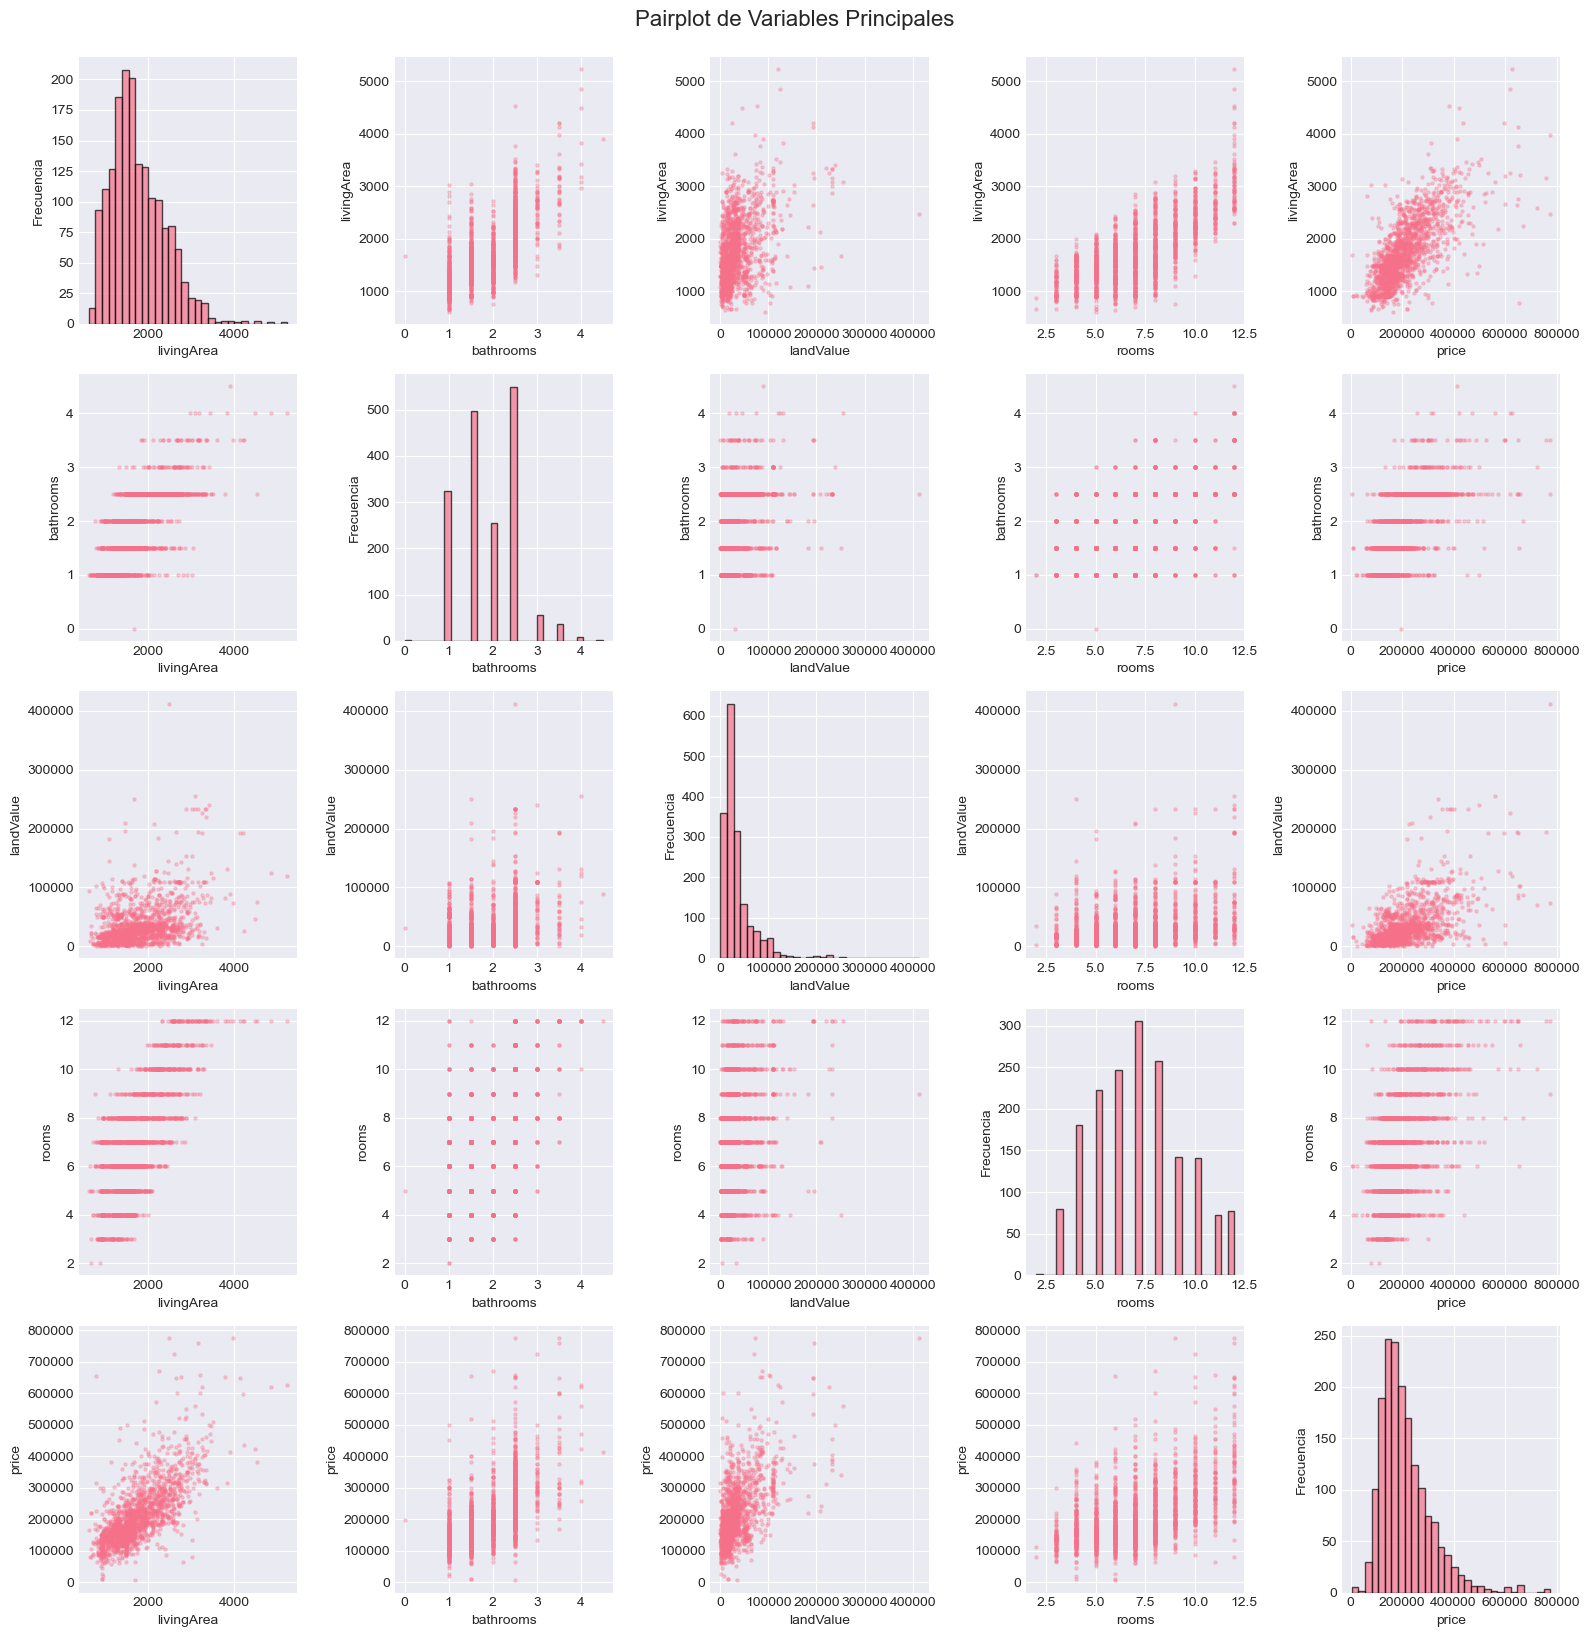

In [19]:
# Pairplot de variables más importantes (usando seaborn)
top_4_vars = price_corr.head(4).index.tolist()
vars_to_plot = top_4_vars + ['price']

fig, axes = plt.subplots(len(vars_to_plot), len(vars_to_plot), figsize=(16, 16))

for i, var1 in enumerate(vars_to_plot):
    for j, var2 in enumerate(vars_to_plot):
        ax = axes[i, j]
        
        if i == j:
            # Diagonal: histograma
            ax.hist(df[var1], bins=30, edgecolor='black', alpha=0.7)
            ax.set_xlabel(var1)
            ax.set_ylabel('Frecuencia')
        else:
            # Scatter plot
            ax.scatter(df[var2], df[var1], alpha=0.3, s=5)
            ax.set_xlabel(var2)
            ax.set_ylabel(var1)

plt.tight_layout()
plt.suptitle('Pairplot de Variables Principales', y=1.02, fontsize=16)
plt.show()

## 11. Feature Engineering - Análisis Preliminar

In [20]:
# Crear nuevas features para análisis
df_feat = df.copy()

# 1. Precio por metro cuadrado habitable
df_feat['price_per_sqft'] = df_feat['price'] / df_feat['livingArea']

# 2. Precio por habitación
df_feat['price_per_room'] = df_feat['price'] / df_feat['rooms']

# 3. Ratio baños/habitaciones
df_feat['bath_per_room'] = df_feat['bathrooms'] / df_feat['rooms']

# 4. Tamaño de lote por dormitorio
df_feat['lot_per_bedroom'] = df_feat['lotSize'] / df_feat['bedrooms']

# 5. Categorías de edad
df_feat['age_category'] = pd.cut(
    df_feat['age'],
    bins=[0, 5, 15, 30, 50, 100, 300],
    labels=['Nueva (0-5)', 'Reciente (6-15)', 'Moderada (16-30)', 
            'Antigua (31-50)', 'Muy Antigua (51-100)', 'Histórica (100+)']
)

# 6. Categorías de área habitable
df_feat['living_area_category'] = pd.cut(
    df_feat['livingArea'],
    bins=[0, 1000, 1500, 2000, 2500, 5000],
    labels=['Pequeña', 'Media-Pequeña', 'Media', 'Media-Grande', 'Grande']
)

# Correlación de nuevas features con el precio
new_features = ['price_per_sqft', 'price_per_room', 'bath_per_room', 'lot_per_bedroom']
new_corrs = {}
for feat in new_features:
    if feat in df_feat.columns:
        valid_data = df_feat[[feat, 'price']].dropna()
        if len(valid_data) > 0:
            new_corrs[feat] = valid_data.corr().iloc[0, 1]

print("=" * 80)
print("🔧 CORRELACIÓN DE NUEVAS FEATURES CON EL PRECIO")
print("=" * 80)

for feat, corr in sorted(new_corrs.items(), key=lambda x: abs(x[1]), reverse=True):
    print(f"{feat:25s}: {corr:>8.4f}")

# Visualización del precio por categoría de edad
fig = px.box(
    df_feat.dropna(subset=['age_category']), 
    x='age_category', y='price',
    title='Distribución del Precio por Categoría de Edad',
    color='age_category'
)
fig.update_xaxes(tickangle=45)
fig.show()

# Visualización del precio por categoría de área habitable
fig = px.box(
    df_feat.dropna(subset=['living_area_category']),
    x='living_area_category', y='price',
    title='Distribución del Precio por Categoría de Área Habitable',
    color='living_area_category'
)
fig.show()

🔧 CORRELACIÓN DE NUEVAS FEATURES CON EL PRECIO
price_per_room           :   0.5998
price_per_sqft           :   0.5539
lot_per_bedroom          :   0.0760
bath_per_room            :   0.0349


## 12. Análisis de Relaciones Multivariadas

In [21]:
# Análisis de cómo livingArea y lotSize afectan el precio
fig = px.scatter_3d(
    df.sample(min(1000, len(df))),
    x='livingArea', y='lotSize', z='price',
    color='price',
    size='bedrooms',
    opacity=0.7,
    title='Relación 3D: Living Area vs Lot Size vs Price',
    labels={'livingArea': 'Área Habitable', 'lotSize': 'Tamaño Lote', 'price': 'Precio'},
    color_continuous_scale='Viridis'
)
fig.update_layout(scene=dict(
    xaxis_title='Área Habitable (m²)',
    yaxis_title='Tamaño Lote (m²)',
    zaxis_title='Precio ($)'
))
fig.show()

In [22]:
# Heatmap de precio promedio por combinación de variables
# Por livingArea y bedrooms
pivot_table = df.pivot_table(
    values='price',
    index=pd.cut(df['bedrooms'], bins=[0, 2, 3, 4, 5, 10], labels=['1-2', '3', '4', '5', '6+']),
    columns=pd.cut(df['livingArea'], bins=[0, 1000, 1500, 2000, 3000, 5000], 
                   labels=['<1000', '1000-1500', '1500-2000', '2000-3000', '3000+']),
    aggfunc='mean'
)

fig = go.Figure(data=go.Heatmap(
    z=pivot_table.values,
    x=pivot_table.columns.astype(str),
    y=pivot_table.index.astype(str),
    colorscale='RdYlGn',
    text=[[f'${v:,.0f}' if not np.isnan(v) else '' for v in row] for row in pivot_table.values],
    texttemplate='%{text}',
    textfont={"size": 10}
))

fig.update_layout(
    title='Precio Promedio por Dormitorios y Área Habitable',
    xaxis_title='Área Habitable (m²)',
    yaxis_title='Dormitorios',
    height=500
)
fig.show()

## 13. Detección y Análisis de Anomalías

In [23]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

# Preparar datos para detección de anomalías
anomaly_features = ['livingArea', 'lotSize', 'age', 'landValue', 'bedrooms', 'bathrooms', 'rooms']
X_anomaly = df[anomaly_features].copy()

# Escalar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_anomaly)

# Isolation Forest
iso_forest = IsolationForest(contamination=0.05, random_state=42)
anomaly_labels = iso_forest.fit_predict(X_scaled)
df['anomaly'] = anomaly_labels

# Resultados
n_anomalies = (anomaly_labels == -1).sum()
print(f"Número de anomalías detectadas: {n_anomalies} ({n_anomalies/len(df)*100:.2f}%)")

# Visualización
fig = px.scatter(
    df, x='livingArea', y='price',
    color=df['anomaly'].map({1: 'Normal', -1: 'Anomalía'}),
    title='Detección de Anomalías: Living Area vs Price',
    opacity=0.7,
    color_discrete_map={'Normal': '#1f77b4', 'Anomalía': '#d62728'}
)
fig.show()

# Análisis de anomalías
print("\n" + "=" * 80)
print("📊 CARACTERÍSTICAS DE LAS ANOMALÍAS")
print("=" * 80)

anomalies_df = df[df['anomaly'] == -1]
normal_df = df[df['anomaly'] == 1]

comparison = pd.DataFrame({
    'Variable': anomaly_features,
    'Media Normal': [normal_df[col].mean() for col in anomaly_features],
    'Media Anomalía': [anomalies_df[col].mean() for col in anomaly_features],
    'Diferencia': [anomalies_df[col].mean() - normal_df[col].mean() for col in anomaly_features]
})
display(comparison.round(2))

Número de anomalías detectadas: 87 (5.03%)



📊 CARACTERÍSTICAS DE LAS ANOMALÍAS


,Variable,Media Normal,Media Anomalía,Diferencia
0,livingArea,1718.24,2447.86,729.62
1,lotSize,0.43,1.80,1.36
2,age,25.93,65.36,39.43
3,landValue,31499.46,92232.18,60732.72
4,bedrooms,3.13,3.61,0.48
5,bathrooms,1.88,2.21,0.33
6,rooms,6.94,8.98,2.04


## 14. Resumen y Conclusiones

In [24]:
print("=" * 80)
print("📋 RESUMEN DEL ANÁLISIS EXPLORATORIO")
print("=" * 80)

print("""
1. CARACTERÍSTICAS DEL DATASET:
   - {} filas y {} columnas
   - Variable objetivo: price (precio de la vivienda)
   - {} variables numéricas y {} variables categóricas

2. VARIABLE OBJETIVO (PRICE):
   - Media: ${:,.2f}
   - Mediana: ${:,.2f}
   - Rango: ${:,.2f} - ${:,.2f}
   - Distribución con asimetría positiva (skewness={:.2f})
   - Recomendación: Considerar transformación logarítmica

3. VARIABLES MÁS CORRELACIONADAS CON EL PRECIO:
   - livingArea (r={:.3f}) - Correlación positiva fuerte
   - bathrooms (r={:.3f}) - Correlación positiva moderada
   - rooms (r={:.3f}) - Correlación positiva moderada
   - fireplaces (r={:.3f}) - Correlación positiva moderada

4. OUTLIERS DETECTADOS:
   - {} anomalías detectadas ({:.2f}% del dataset)
   - Variables con más outliers: lotSize, age, landValue

5. FEATURES RECOMENDADAS PARA EL MODELO:
   - Originales: livingArea, bathrooms, rooms, fireplaces, landValue, age
   - Derivadas: price_per_sqft, bath_per_room, age_category

6. INSIGHTS PARA MODELADO:
   - La relación livingArea-price es la más fuerte
   - Propiedades con vista al lago tienen precio premium
   - Propiedades nuevas tienen mayor valor
   - Aire acondicionado central aumenta el valor
   - El vecindario con mayor educación correlaciona con mayor precio
""".format(
    len(df), len(df.columns),
    len(numeric_cols), len(categorical_cols),
    df['price'].mean(), df['price'].median(),
    df['price'].min(), df['price'].max(), df['price'].skew(),
    price_corr.get('livingArea', 0), price_corr.get('bathrooms', 0),
    price_corr.get('rooms', 0), price_corr.get('fireplaces', 0),
    n_anomalies, n_anomalies/len(df)*100
))

📋 RESUMEN DEL ANÁLISIS EXPLORATORIO

1. CARACTERÍSTICAS DEL DATASET:
   - 1728 filas y 17 columnas
   - Variable objetivo: price (precio de la vivienda)
   - 10 variables numéricas y 6 variables categóricas

2. VARIABLE OBJETIVO (PRICE):
   - Media: $211,966.71
   - Mediana: $189,900.00
   - Rango: $5,000.00 - $775,000.00
   - Distribución con asimetría positiva (skewness=1.58)
   - Recomendación: Considerar transformación logarítmica

3. VARIABLES MÁS CORRELACIONADAS CON EL PRECIO:
   - livingArea (r=0.712) - Correlación positiva fuerte
   - bathrooms (r=0.597) - Correlación positiva moderada
   - rooms (r=0.531) - Correlación positiva moderada
   - fireplaces (r=0.377) - Correlación positiva moderada

4. OUTLIERS DETECTADOS:
   - 87 anomalías detectadas (5.03% del dataset)
   - Variables con más outliers: lotSize, age, landValue

5. FEATURES RECOMENDADAS PARA EL MODELO:
   - Originales: livingArea, bathrooms, rooms, fireplaces, landValue, age
   - Derivadas: price_per_sqft, bath_per_

In [25]:
# Guardar datos procesados para modelado
output_path = PROJECT_ROOT / "data" / "processed" / "eda_processed_data.csv"
output_path.parent.mkdir(parents=True, exist_ok=True)
df_feat.to_csv(output_path, index=False)
print(f"✅ Datos procesados guardados en: {output_path}")

# Guardar resumen de estadísticas
summary_path = PROJECT_ROOT / "data" / "processed" / "eda_summary.csv"
summary_df = pd.DataFrame([price_stats]).T
summary_df.columns = ['Valor']
summary_df.to_csv(summary_path)
print(f"✅ Resumen guardado en: {summary_path}")

✅ Datos procesados guardados en: d:\Users\alexa\Saratoga_Houses\data\processed\eda_processed_data.csv
✅ Resumen guardado en: d:\Users\alexa\Saratoga_Houses\data\processed\eda_summary.csv


## 15. Visualizaciones Adicionales para Reportes

In [26]:
# Dashboard resumen
fig = make_subplots(
    rows=2, cols=3,
    subplot_titles=(
        'Distribución del Precio',
        'Top 5 Correlaciones con Precio',
        'Precio por Tipo de Calefacción',
        'Precio por Vista al Lago',
        'Precio por Aire Acondicionado',
        'Precio por Nueva Construcción'
    ),
    specs=[[{"type": "histogram"}, {"type": "bar"}, {"type": "bar"}],
           [{"type": "bar"}, {"type": "bar"}, {"type": "bar"}]]
)

# 1. Distribución del precio
fig.add_trace(
    go.Histogram(x=df['price'], nbinsx=50, name='Precio', marker_color='#1f77b4'),
    row=1, col=1
)

# 2. Top 5 correlaciones
top_5_corr = price_corr.head(5)
fig.add_trace(
    go.Bar(x=top_5_corr.index, y=top_5_corr.values, 
           text=top_5_corr.values.round(3), textposition='outside',
           marker_color='#ff7f0e'),
    row=1, col=2
)

# 3. Precio por calefacción
heating_means = df.groupby('heating')['price'].mean().sort_values()
fig.add_trace(
    go.Bar(x=heating_means.index, y=heating_means.values,
           text=[f'${v:,.0f}' for v in heating_means.values], textposition='outside',
           marker_color='#2ca02c'),
    row=1, col=3
)

# 4. Precio por waterfront
waterfront_means = df.groupby('waterfront')['price'].mean()
fig.add_trace(
    go.Bar(x=waterfront_means.index, y=waterfront_means.values,
           text=[f'${v:,.0f}' for v in waterfront_means.values], textposition='outside',
           marker_color=['#1f77b4', '#d62728']),
    row=2, col=1
)

# 5. Precio por centralAir
air_means = df.groupby('centralAir')['price'].mean()
fig.add_trace(
    go.Bar(x=air_means.index, y=air_means.values,
           text=[f'${v:,.0f}' for v in air_means.values], textposition='outside',
           marker_color=['#9467bd', '#8c564b']),
    row=2, col=2
)

# 6. Precio por newConstruction
new_means = df.groupby('newConstruction')['price'].mean()
fig.add_trace(
    go.Bar(x=new_means.index, y=new_means.values,
           text=[f'${v:,.0f}' for v in new_means.values], textposition='outside',
           marker_color=['#e377c2', '#7f7f7f']),
    row=2, col=3
)

fig.update_layout(
    height=800,
    showlegend=False,
    title_text="Dashboard de Análisis - Saratoga Houses"
)
fig.show()

In [27]:
print("\n" + "=" * 80)
print("✅ ANÁLISIS EXPLORATORIO COMPLETADO EXITOSAMENTE")
print("=" * 80)
print("\n📁 Archivos generados:")
print(f"   - {output_path}")
print(f"   - {summary_path}")
print("\n🔍 Principales hallazgos:")
print("   1. Dataset limpio sin valores nulos")
print("   2. livingArea es el predictor más fuerte del precio")
print("   3. Vista al lago y aire acondicionado aumentan significativamente el valor")
print("   4. Se recomienda transformación logarítmica del precio para modelado")
print("   5. Las variables categóricas muestran patrones claros de diferenciación de precios")
print("\n🚀 Listo para la fase de modelado!")


✅ ANÁLISIS EXPLORATORIO COMPLETADO EXITOSAMENTE

📁 Archivos generados:
   - d:\Users\alexa\Saratoga_Houses\data\processed\eda_processed_data.csv
   - d:\Users\alexa\Saratoga_Houses\data\processed\eda_summary.csv

🔍 Principales hallazgos:
   1. Dataset limpio sin valores nulos
   2. livingArea es el predictor más fuerte del precio
   3. Vista al lago y aire acondicionado aumentan significativamente el valor
   4. Se recomienda transformación logarítmica del precio para modelado
   5. Las variables categóricas muestran patrones claros de diferenciación de precios

🚀 Listo para la fase de modelado!
